# YAFS Simulation Trace Analysis

This notebook analyzes the `sim_trace.csv` file generated by the YAFS simulation. It focuses on:
- **Latency Analysis**: End-to-end delay of messages.
- **Service Time**: Processing time within modules.
- **Traffic Distribution**: Message counts per application and module.
- **Topology Flow**: Communication patterns between Fog and Cloud nodes.

In [195]:
# Install analysis dependencies (idempotent)
%pip install -q pandas matplotlib seaborn numpy

Note: you may need to restart the kernel to use updated packages.


In [196]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path

# Set plot style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Load and Inspect Data
Load the CSV file and check the structure.

In [197]:
# Load the dataset
# Update to the specific results file generated by the tutorial
file_to_load = "cloud1-gateway12-fog12-end48"
strategy = "roundrobin"
file_path = f"resultados/{file_to_load}-{strategy}-sim_trace.csv"
df = pd.read_csv(file_path)

# Display first rows
display(df.head())

# Check info
print(df.info())

,id,type,app,module,message,DES.src,DES.dst,TOPO.src,TOPO.dst,TOPO.srcLabel,TOPO.dstLabel,module.src,service,time_in,time_out,time_emit,time_reception
0,47,COMP_M,Application-47,Application-47-Service,M_Req,140,141,72,25,EndDevice-47,Fog-12,Application-47-EndDevice,0.024000,104.0,104.024000,100.0,104.0
1,15,COMP_M,Application-15,Application-15-Service,M_Req,44,45,40,9,EndDevice-15,Fog-4,Application-15-EndDevice,0.052296,104.0,104.052296,100.0,104.0
2,31,COMP_M,Application-31,Application-31-Service,M_Req,92,93,56,17,EndDevice-31,Fog-8,Application-31-EndDevice,0.018370,104.0,104.018370,100.0,104.0
3,25,COMP_M,Application-25,Application-25-Service,M_Req,74,75,50,5,EndDevice-25,Fog-2,Application-25-EndDevice,0.049037,108.0,108.049037,100.0,108.0
4,43,COMP_M,Application-43,Application-43-Service,M_Req,128,129,68,17,EndDevice-43,Fog-8,Application-43-EndDevice,0.022148,108.0,108.022148,100.0,108.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46510 entries, 0 to 46509
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              46510 non-null  int64  
 1   type            46510 non-null  object 
 2   app             46510 non-null  object 
 3   module          46510 non-null  object 
 4   message         46510 non-null  object 
 5   DES.src         46510 non-null  int64  
 6   DES.dst         46510 non-null  int64  
 7   TOPO.src        46510 non-null  int64  
 8   TOPO.dst        46510 non-null  int64  
 9   TOPO.srcLabel   46510 non-null  object 
 10  TOPO.dstLabel   46510 non-null  object 
 11  module.src      46510 non-null  object 
 12  service         46510 non-null  float64
 13  time_in         46510 non-null  float64
 14  time_out        46510 non-null  float64
 15  time_emit       46510 non-null  float64
 16  time_reception  46510 non-null  float64
dtypes: float64(5), int64(5), object

## 2. Data Preprocessing
Calculate key metrics:
- **Latency**: `service`
- **Service Time**: `time_out - time_in`
- **Network/Wait Time**: `Latency - Service Time`

In [198]:
# Calculate Latency (Convert to ms)
df['Latency'] = df['service'] * 1000

# Calculate Service Time (Processing Duration) (Convert to ms)
df['Service_Time'] = (df['time_out'] - df['time_in']) * 1000

# Calculate Network + Wait Time
df['Network_Wait_Time'] = df['Latency'] - df['Service_Time']

# Create a combined label for Application and Node
df['App_Node'] = df['app'] + ' (' + df['TOPO.dstLabel'] + ')'

# Display summary stats for these new metrics
df[['Latency', 'Service_Time', 'Network_Wait_Time']].describe()

,Latency,Service_Time,Network_Wait_Time
count,46510.000000,46510.000000,4.651000e+04
mean,19.598996,19.598996,-1.645466e-11
std,22.800791,22.800791,4.860760e-09
min,0.001712,0.001712,-3.636378e-08
25%,0.004284,0.004284,-1.796913e-09
50%,7.412037,7.412037,-4.312994e-12
75%,34.814815,34.814815,1.761912e-09
max,74.074074,74.074074,3.617426e-08


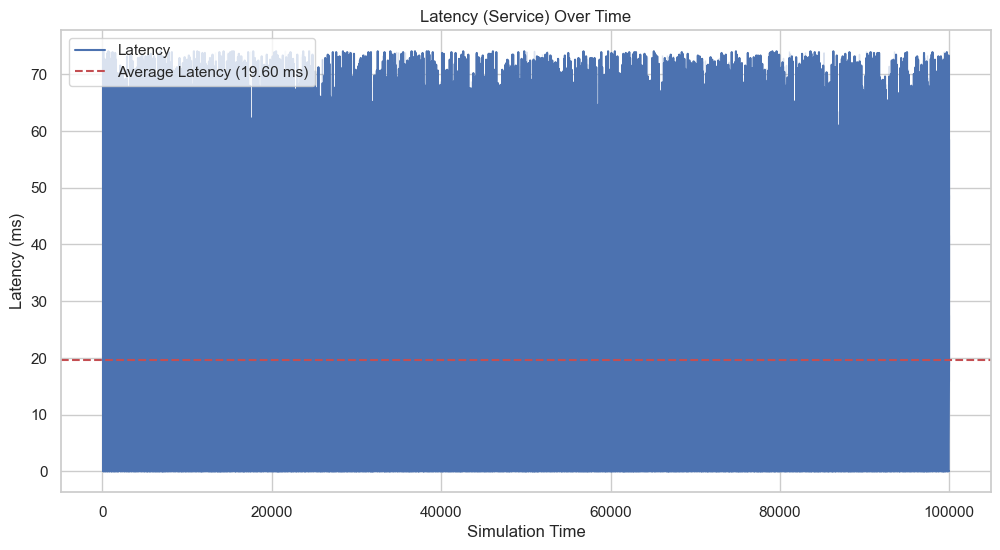

In [199]:
# Simple Line Plot: Latency (Service) over Time
plt.figure(figsize=(12, 6))
sns.lineplot(x='time_reception', y='Latency', data=df, label='Latency')

# Calculate and plot average
mean_latency = df['Latency'].mean()
plt.axhline(y=mean_latency, color='r', linestyle='--', label=f'Average Latency ({mean_latency:.2f} ms)')

plt.title('Latency (Service) Over Time')
plt.xlabel('Simulation Time')
plt.ylabel('Latency (ms)')
plt.legend()
plt.show()

## 3. Descriptive Statistics
Analyze the frequency of applications, modules, and message types.

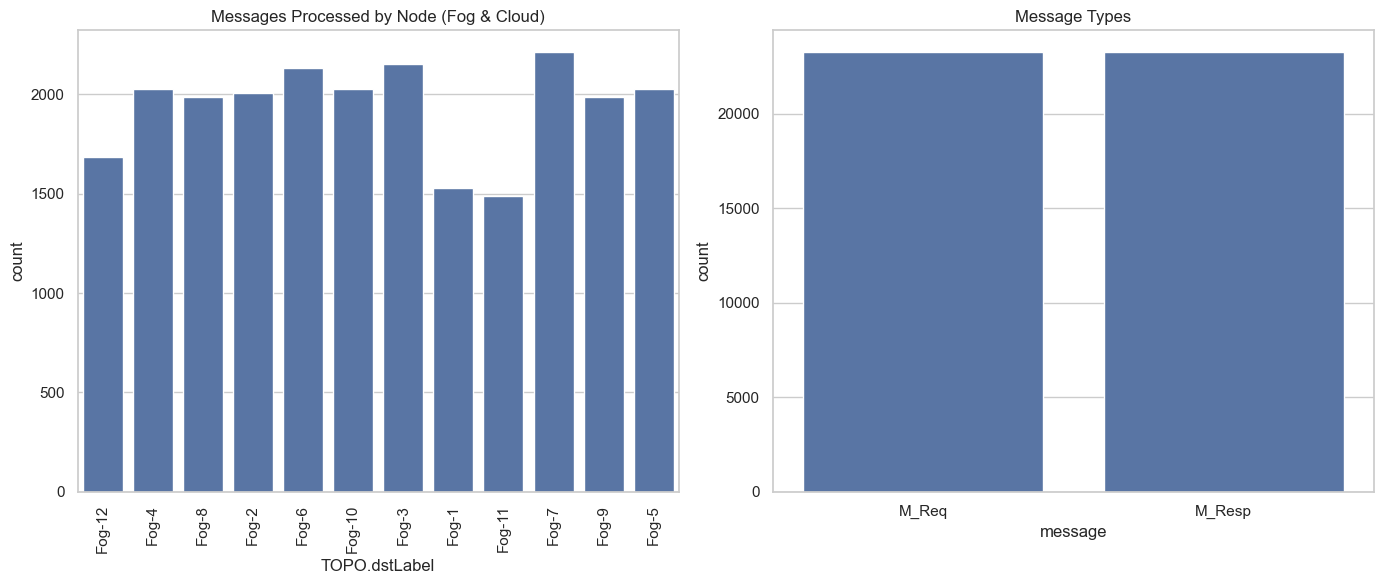

In [200]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Messages Processed by Node (Physical Node only)
# Filter for M_Req messages to show only Fog/Cloud nodes (Service providers)
# M_Resp messages go back to Sensors (Users), so we exclude them here.
df_fog_cloud = df[df['message'] == 'M_Req']
sns.countplot(x='TOPO.dstLabel', data=df_fog_cloud, ax=axes[0])
axes[0].set_title('Messages Processed by Node (Fog & Cloud)')
axes[0].tick_params(axis='x', rotation=90)

# 2. Message Types
# We use the 'message' column to distinguish M_Req, M_Resp, M_Act
sns.countplot(x='message', data=df, ax=axes[1])
axes[1].set_title('Message Types')

plt.tight_layout()
plt.show()

## 4. Latency Analysis
Visualize the distribution of latency and compare it across applications.

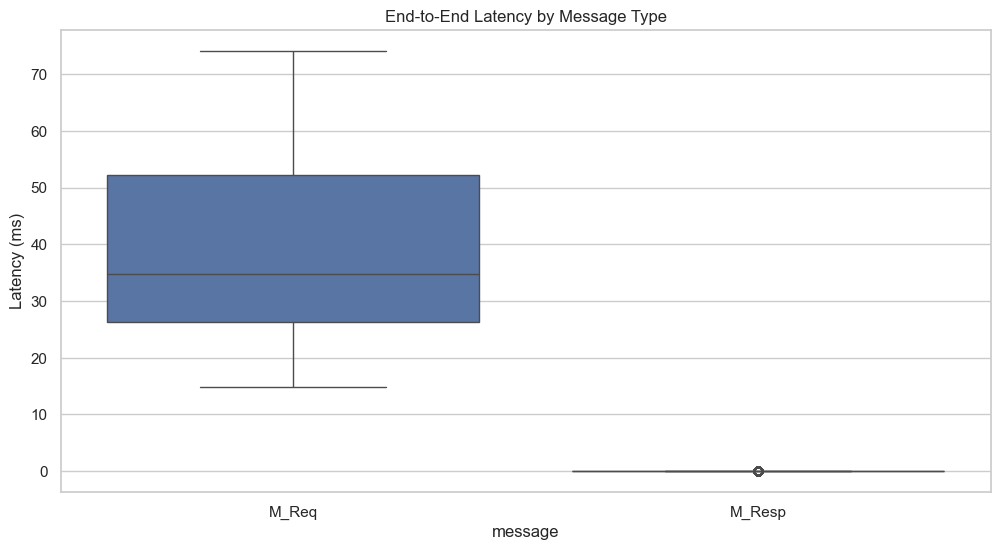

In [201]:
# Latency Distribution by Message Type
plt.figure(figsize=(12, 6))
sns.boxplot(x='message', y='Latency', data=df)
plt.title('End-to-End Latency by Message Type')
plt.ylabel('Latency (ms)')
plt.show()

## 5. Service Time Analysis
Compare processing times across different nodes (Fog vs Cloud).

## 6. Traffic Load Over Time
Check if the traffic is constant or bursty.

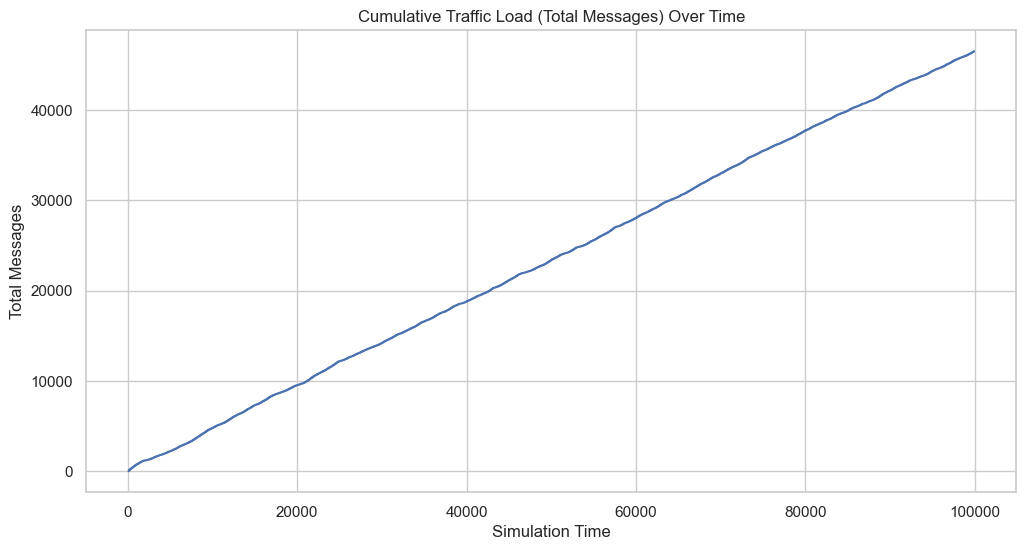

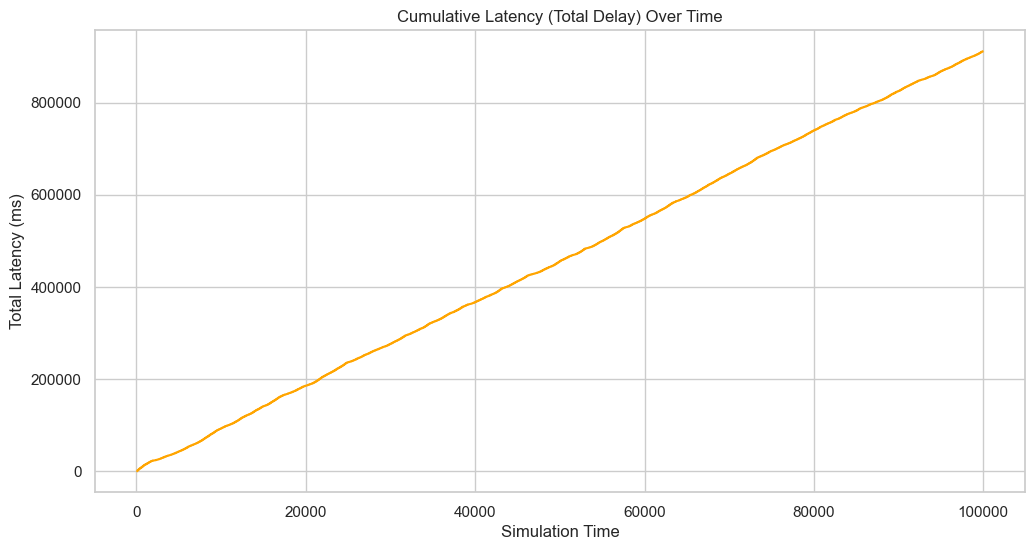

In [202]:
# Sort by time_reception to ensure correct cumulative sum
df_sorted = df.sort_values('time_reception')

# Calculate cumulative sum of messages
df_sorted['cumulative_messages'] = np.arange(1, len(df_sorted) + 1)

# Calculate cumulative sum of latency (in ms)
df_sorted['cumulative_latency'] = (df_sorted['service'] * 1000).cumsum()

# Plot 1: Cumulative Messages
plt.figure(figsize=(12, 6))
sns.lineplot(x='time_reception', y='cumulative_messages', data=df_sorted)
plt.title('Cumulative Traffic Load (Total Messages) Over Time')
plt.xlabel('Simulation Time')
plt.ylabel('Total Messages')
plt.show()

# Plot 2: Cumulative Latency
plt.figure(figsize=(12, 6))
sns.lineplot(x='time_reception', y='cumulative_latency', data=df_sorted, color='orange')
plt.title('Cumulative Latency (Total Delay) Over Time')
plt.xlabel('Simulation Time')
plt.ylabel('Total Latency (ms)')
plt.show()

## 7. Network Topology Flow
Visualize the communication frequency between different nodes.

In [203]:
# Create a pivot table (crosstab) showing communication frequency
communication_table = pd.crosstab(df['TOPO.srcLabel'], df['TOPO.dstLabel'])

print("Communication Table (Source Node vs Destination Node):")
display(communication_table)

Communication Table (Source Node vs Destination Node):


TOPO.dstLabel,EndDevice-1,EndDevice-10,EndDevice-11,EndDevice-12,EndDevice-13,EndDevice-14,EndDevice-15,EndDevice-16,EndDevice-17,EndDevice-18,...,Fog-11,Fog-12,Fog-2,Fog-3,Fog-4,Fog-5,Fog-6,Fog-7,Fog-8,Fog-9
TOPO.srcLabel,,,,,,,,,,,,,,,,,,,,,
EndDevice-1,0,0,0,0,0,0,0,0,0,0,...,0,0,867,0,0,0,0,0,0,0
EndDevice-10,0,0,0,0,0,0,0,0,0,0,...,441,0,0,0,0,0,0,0,0,0
EndDevice-11,0,0,0,0,0,0,0,0,0,0,...,0,468,0,0,0,0,0,0,0,0
EndDevice-12,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
EndDevice-13,0,0,0,0,0,0,0,0,0,0,...,0,0,399,0,0,0,0,0,0,0
EndDevice-14,0,0,0,0,0,0,0,0,0,0,...,0,0,0,419,0,0,0,0,0,0
EndDevice-15,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,379,0,0,0,0,0
EndDevice-16,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,384,0,0,0,0
EndDevice-17,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,411,0,0,0


## 8. Conclusion
This notebook provides a comprehensive overview of the simulation results.
- **Latency**: Check the boxplots to see if any application suffers from high latency.
- **Service Time**: Compare Fog vs Cloud nodes to see if Fog nodes are processing faster or if they are overloaded.
- **Traffic**: Ensure the load is distributed as expected and not saturating specific nodes (check the Heatmap).

## 6. Unprocessed Messages Analysis (Congestion/Loss)
Analyze messages that did not complete before the simulation ended. This indicates severe congestion or bottlenecks.

In [204]:
import os

unprocessed_path = 'resultados/unprocessed_messages.csv'

if os.path.exists(unprocessed_path):
    df_unprocessed = pd.read_csv(unprocessed_path)
    
    print(f"Total Unprocessed Messages: {len(df_unprocessed)}")
    
    if len(df_unprocessed) > 0:
        display(df_unprocessed.head())
        
        # 1. Count by Queue Type
        plt.figure(figsize=(8, 5))
        sns.countplot(x='QueueType', data=df_unprocessed)
        plt.title('Unprocessed Messages by Queue Type')
        plt.show()
        
        # 2. Count by Application (Top 20)
        top_stuck_apps = df_unprocessed['App'].value_counts().nlargest(20).index
        df_stuck_top20 = df_unprocessed[df_unprocessed['App'].isin(top_stuck_apps)]
        
        plt.figure(figsize=(12, 6))
        sns.countplot(x='App', data=df_stuck_top20, order=top_stuck_apps)
        plt.title('Stuck Messages by Application (Top 20)')
        plt.xticks(rotation=45, ha='right')
        plt.show()
        
        # 3. Distribution of "Until" time (Projected Completion Time)
        # Filter out N/A values if any
        df_unprocessed['Until'] = pd.to_numeric(df_unprocessed['Until'], errors='coerce')
        
        plt.figure(figsize=(10, 6))
        sns.histplot(df_unprocessed['Until'].dropna(), kde=True, color='red')
        plt.title('Projected Completion Time of Stuck Messages')
        plt.xlabel('Simulation Time')
        plt.show()
        
    else:
        print("No unprocessed messages found. Great!")
else:
    print("unprocessed_messages.csv not found.")

Total Unprocessed Messages: 0
No unprocessed messages found. Great!


## 9. Failures Over Time
Load the failure trace (same basename as `file_path` with `_failure.csv`) and plot how failures accumulate over the simulation.

Loaded failure metrics from resultados/cloud1-gateway12-fog12-end48-roundrobin-sim_trace_failure.csv


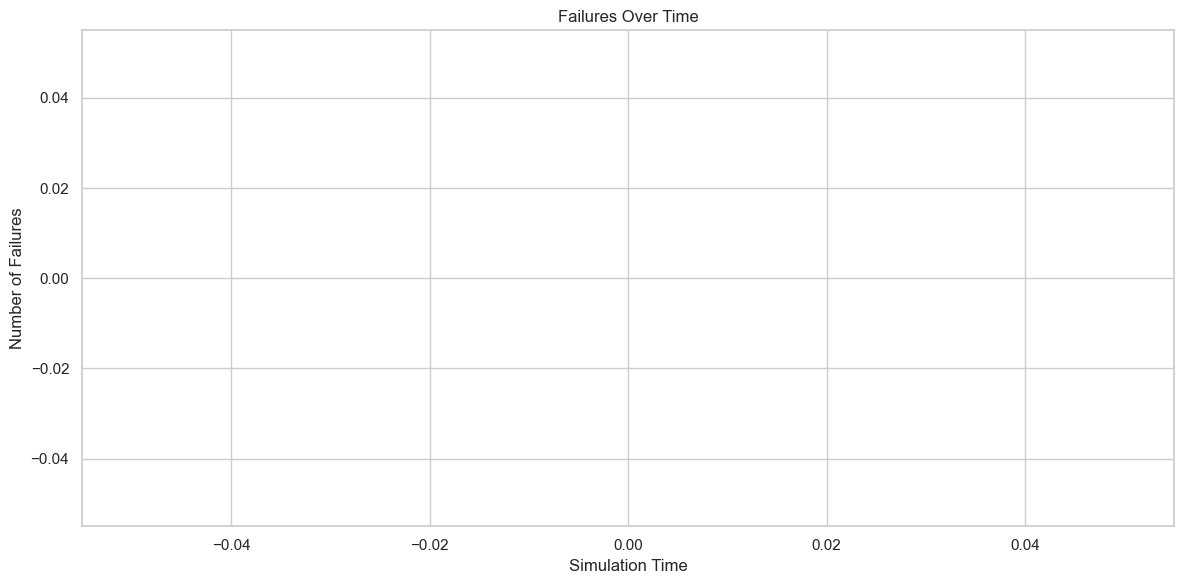

In [205]:
failure_path = Path(file_path).with_name(Path(file_path).stem + "_failure.csv")
df_failure = None

if failure_path.exists():
    df_failure = pd.read_csv(failure_path)
    print(f"Loaded failure metrics from {failure_path}")
else:
    print(f"No failure metrics file found at {failure_path}")

if df_failure is not None:
    time_col = None
    for candidate in ["ctime", "time", "time_reception", "time_emit", "timestamp", "time_in", "time_out", "t"]:
        if candidate in df_failure.columns:
            time_col = candidate
            break

    if time_col is None:
        print("No time-like column found in failure metrics; available columns:", df_failure.columns.tolist())
    else:
        df_failure["time_bin"] = df_failure[time_col].astype(float).round().astype(int)
        failures_over_time = df_failure.groupby("time_bin").size().reset_index(name="failures")
        plt.figure(figsize=(12, 6))
        sns.lineplot(x="time_bin", y="failures", data=failures_over_time, marker="o")
        plt.title("Failures Over Time")
        plt.xlabel("Simulation Time")
        plt.ylabel("Number of Failures")
        plt.tight_layout()
        plt.show()

## 10. Node Counts Over Time
Visualize how many nodes remain active across the simulation. This reads the `*_node_counts.csv` generated by the simulator and plots total nodes (and per-role counts when available).

Loaded node counts from resultados/cloud1-gateway12-fog12-end48-roundrobin-sim_trace_node_counts.csv


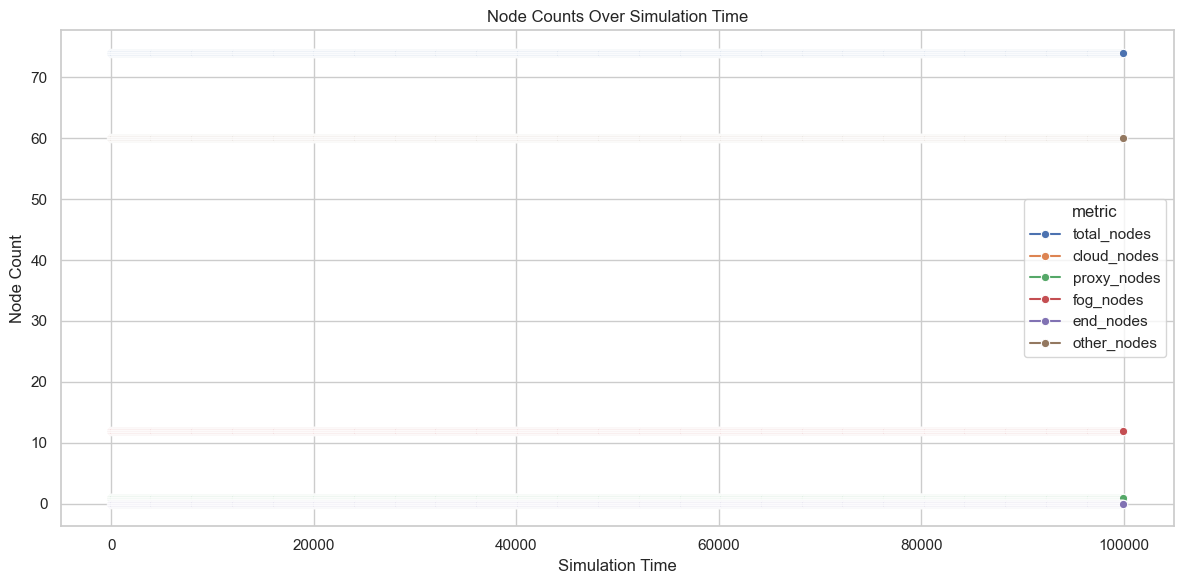

,time,total_nodes,cloud_nodes,proxy_nodes,fog_nodes,end_nodes,other_nodes
0,0.0,74,1,1,12,0,60
1,50.0,74,1,1,12,0,60
2,100.0,74,1,1,12,0,60
3,150.0,74,1,1,12,0,60
4,200.0,74,1,1,12,0,60


In [206]:
node_counts_path = Path(file_path).with_name(Path(file_path).stem + "_node_counts.csv")
node_counts_df = None

if node_counts_path.exists():
    node_counts_df = pd.read_csv(node_counts_path)
    print(f"Loaded node counts from {node_counts_path}")
else:
    print(f"Node counts file not found: {node_counts_path}")

if node_counts_df is not None and not node_counts_df.empty:
    if "time" not in node_counts_df.columns:
        print("Missing required 'time' column in node counts data.")
    else:
        node_counts_df["time"] = node_counts_df["time"].astype(float)
        value_cols = [
            col
            for col in [
                "total_nodes",
                "cloud_nodes",
                "proxy_nodes",
                "fog_nodes",
                "end_nodes",
                "other_nodes",
            ]
            if col in node_counts_df.columns
        ]

        if not value_cols:
            print("No count columns found in node counts data.")
        else:
            melted = node_counts_df.melt(
                id_vars="time", value_vars=value_cols, var_name="metric", value_name="count"
            )

            plt.figure(figsize=(12, 6))
            sns.lineplot(x="time", y="count", hue="metric", data=melted, marker="o")
            plt.title("Node Counts Over Simulation Time")
            plt.xlabel("Simulation Time")
            plt.ylabel("Node Count")
            plt.tight_layout()
            plt.show()

            display(node_counts_df.head())